In [ ]:
# Importing ibraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve


# handling imbalance
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Loading Dataset
df= pd.read_csv('/content/creditcard.csv')

# First 5 rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.shape

(284807, 31)

In [ ]:
# checking nul values
df.isnull().sum()
print(df.isnull().sum)

<bound method DataFrame.sum of          Time     V1     V2     V3     V4     V5     V6     V7     V8     V9  \
0       False  False  False  False  False  False  False  False  False  False   
1       False  False  False  False  False  False  False  False  False  False   
2       False  False  False  False  False  False  False  False  False  False   
3       False  False  False  False  False  False  False  False  False  False   
4       False  False  False  False  False  False  False  False  False  False   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
284802  False  False  False  False  False  False  False  False  False  False   
284803  False  False  False  False  False  False  False  False  False  False   
284804  False  False  False  False  False  False  False  False  False  False   
284805  False  False  False  False  False  False  False  False  False  False   
284806  False  False  False  False  False  False  False  False  False  False   

        

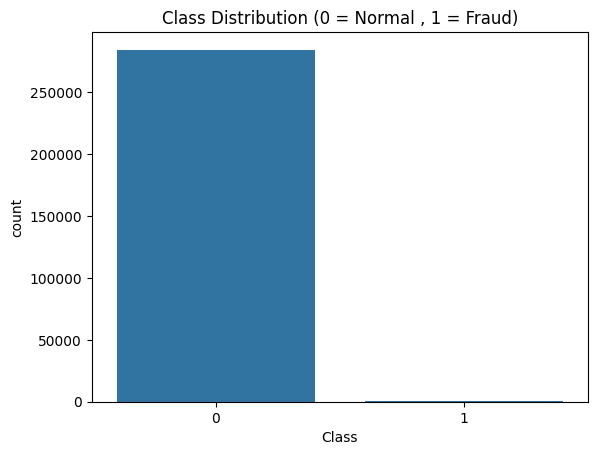

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [ ]:
# Plotting class imbalance
sns.countplot(x='Class',data=df)
plt.title("Class Distribution (0 = Normal , 1 = Fraud)")
plt.show()

print(df['Class'].value_counts(normalize=True))



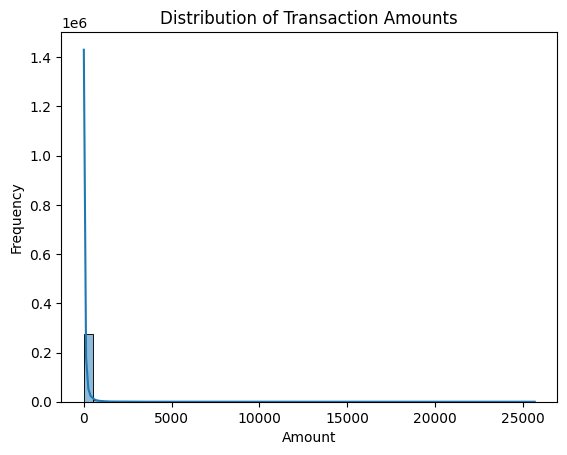

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [ ]:
# Distribution of the amount
sns.histplot(df['Amount'],bins=50,kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


# summary statistics of the amount
print(df["Amount"].describe())

In [ ]:
# Handling NAN values in target column "Class"
df=df.dropna(subset=['Class'])


In [ ]:
#Features and target

X=df.drop("Class",axis=1)
y=df["Class"]

#Stratified split to keep Class Ratio
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

print("Train shape",X_train.shape,y_train.shape)
print("Test shape",x_test.shape,y_test.shape)


Train shape (227845, 30) (227845,)
Test shape (56962, 30) (56962,)


In [ ]:

# Decision Tree

dt= DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# predictions
y_predict=dt.predict(x_test)

#Evaluation
print("Classification Report",classification_report(y_test,y_predict))
print("/n Confusion_matrix",confusion_matrix(y_test,y_predict))



#ROC_AUC
y_prob=dt.predict_proba(x_test)[:,1]
roc_auc=roc_auc_score(y_test,y_prob)
print("ROC AUC Score",roc_auc)






Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962

/n Confusion_matrix [[56840    24]
 [   25    73]]
0.9991397773954567
ROC AUC Score 0.8722379497662881


In [ ]:
# SMOTE
smote=SMOTE(random_state=42)
x_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)


# Train Decision tree on SMOTE data
dt_sm=DecisionTreeClassifier(random_state=42)
dt_sm.fit(X_train_sm,y_train_sm)


# predict on test data
y_pred_sm=dt_sm.predict(x_test)


#Evaluation
print("Classification Report",classification_report(y_test,y_pred_sm))
print("Confusion Matrix",confusion_matrix(y_test,y_pred_sm))


#ROC-AUC
y_prob_sm=dt_sm.predict_proba(x_test)[:,1]
roc_auc_sm=roc_auc_score(y_test,y_prob_sm)
print("ROC AUC Score",roc_auc_sm)



Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.80      0.55        98

    accuracy                           1.00     56962
   macro avg       0.71      0.90      0.78     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix [[56758   106]
 [   20    78]]
ROC AUC Score 0.897027135277296


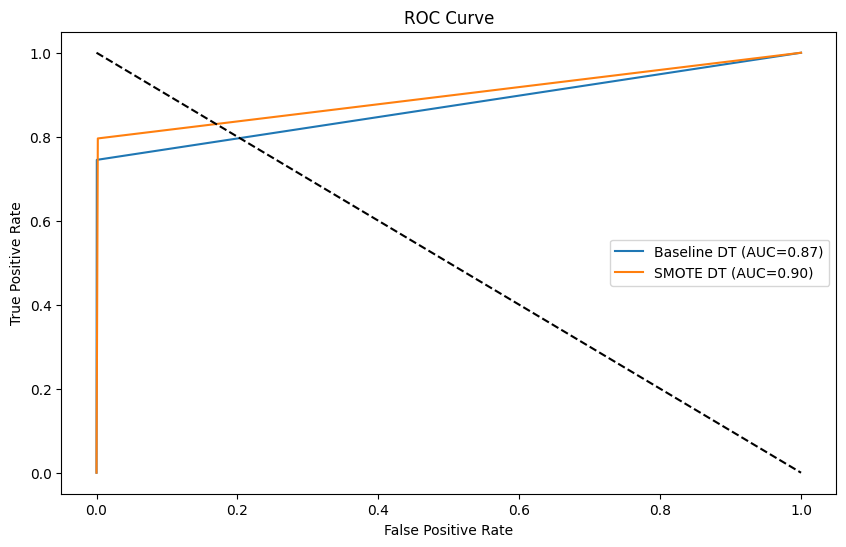

In [ ]:

# ROC Curve
FPR,TPR,thresholds=roc_curve(y_test,y_prob)
FPR_sm,TPR_sm,thresholds_sm=roc_curve(y_test,y_prob_sm)

plt.figure(figsize=(10,6))
plt.plot(FPR,TPR,label=f"Baseline DT (AUC={roc_auc:.2f})")
plt.plot(FPR_sm,TPR_sm,label=f"SMOTE DT (AUC={roc_auc_sm:.2f})")
plt.plot([0,1],[1,0],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
# Hyperparameter tuning

param_grid={
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,5,10]

}

grid=GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5,scoring='roc_auc',n_jobs=-1)
grid.fit(X_train,y_train)


print("Best Parameters",grid.best_params_)

best_dt = grid.best_estimator_
print("Best Score", best_dt)


y_predict_best=best_dt.predict(x_test)
y_prob_best=best_dt.predict_proba(x_test)[:,1]
roc_auc_best=roc_auc_score(y_test,y_prob_best)
print( "ROC AUC Score(BEST DT)",roc_auc_best)

Best Parameters {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Score DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
ROC AUC Score(BEST DT) 0.9180663243772467


**Accuracy cant be used in this dataset as it is imbalanced data**


**Write an explanation of why SMOTE is not a good practice with decision trees, and explain the results**


> SMOTE is not a good practice with Decision Trees because trees split data based on exact feature values, and synthetic samples created by SMOTE can introduce noise and lead to overfitting. Decision Trees do not benefit much from distance-based oversampling methods like SMOTE.
>
> In the results, SMOTE increased recall for fraud cases but reduced precision and showed little or no improvement in ROC-AUC. This indicates that the model learned synthetic patterns rather than generalizable fraud behavior.



**Describtion of the EDA**


*   The amount is Right Skewed
*   the shape of the data 284807 rows and 31 column
*   the data is imbalanced
*  there are no missing values in the class column









